## 4.1 Definirea problemei

In cadrul acestui proiect am analizat problema predictiei calitatii vinului pe baza caracteristicilor sale chimice. Scopul este de a construi modele de machine learning capabile sa estimeze scorul de calitate al unui vin folosind datele disponibile.

Problema abordata este una de regresie, deoarece variabila de iesire este numerica. Am urmarit prezicerea variabilei *quality*, care reprezinta scorul calitatii vinului, pe baza unor caracteristici precum *alcohol*, *volatile acidity*, *sulphates*, *pH*, *density* si altele.

Variabilele de intrare sunt reprezentate de proprietatile fizico-chimice ale vinului, iar variabila de iesire este *quality*. Aceasta are valori discrete in intervalul [3, 8] si reflecta evaluarea calitatii vinului.

Am ales acest set de date deoarece combina un domeniu real (industria vinului) cu o problema de regresie bine definita, permitand aplicarea si compararea mai multor algoritmi de machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# modelele
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from interpret.glassbox import ExplainableBoostingRegressor

from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve

D:\university_sem2_3rd_year\is\Ass1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 4.2 Analiza exploratorie a datelor si pregatirea lor

In aceasta etapa am realizat o analiza exploratorie a datelor (EDA) pentru a intelege structura, calitatea si distributia variabilelor din dataset.

Initial, s-au analizat informatiile generale despre date folosind metode precum `info()` si `describe()`. Datasetul contine 1599 de observatii si 12 variabile, dintre care 11 sunt caracteristici numerice si una reprezinta variabila tinta (*quality*).

Din punct de vedere al tipurilor de date, toate variabilele sunt numerice, ceea ce permite utilizarea directa in modelele de machine learning fara transformari suplimentare.

Analiza distributiei variabilei tinta a fost realizata folosind o histograma. Se poate vedea ca majoritatea valorilor sunt concentrate in jurul lui 5 si 6, indicand o distributie dezechilibrata catre valori medii.

Pentru a analiza relatiile dintre variabile, am utilizat o matrice de corelatii. Aceasta a evidentiat faptul ca variabile precum *alcohol* si *sulphates* au o corelatie pozitiva cu calitatea vinului, in timp ce *volatile acidity* prezinta o corelatie negativa.

Nu au fost identificate valori lipsa sau anomalii semnificative care sa necesite eliminarea sau corectarea datelor. Am folosit datasetul in forma sa initiala.

Pentru pregatirea datelor, le-am impartit in seturi de antrenare si testare (75% - 25%). De asemenea, am aplicat normalizarea folosind StandardScaler pentru modelele sensibile la scala datelor, precum SVR, KNN si Gaussian Process.


In [2]:
df = pd.read_csv("winequality-red.csv", sep=";")

print(df.head())
print(df.info())
print(df.describe())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

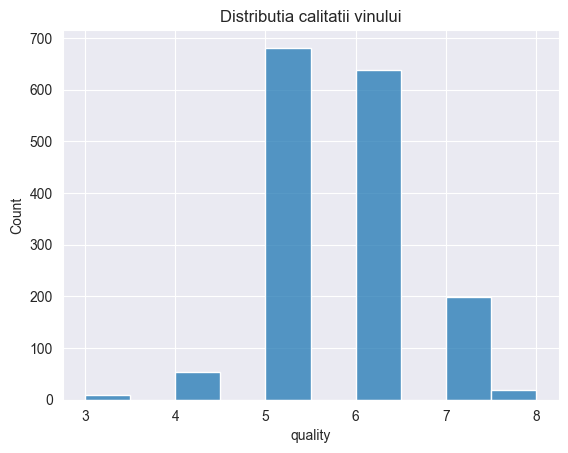

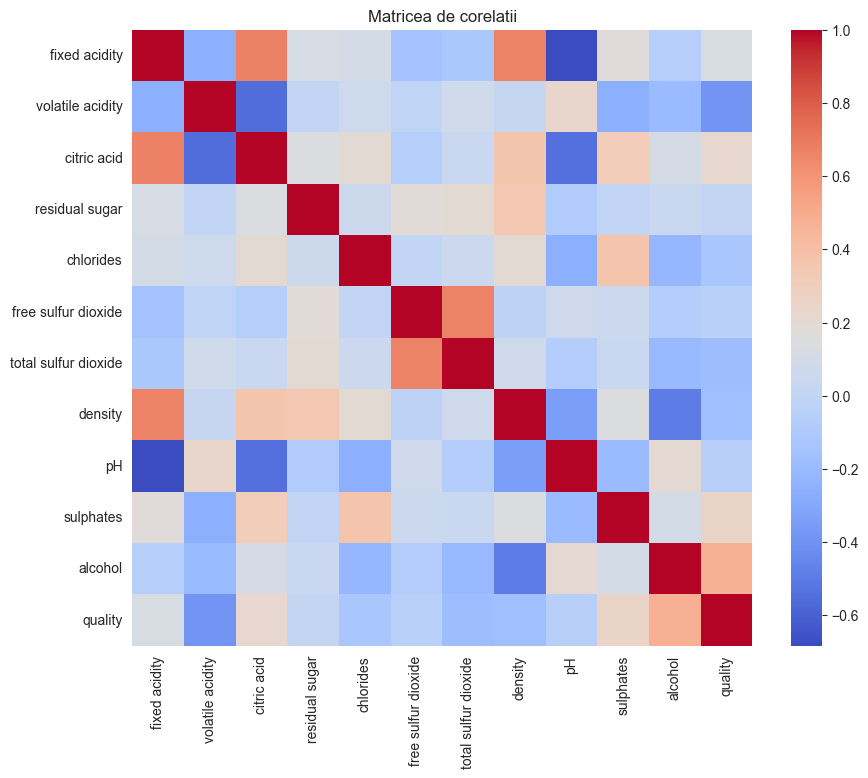

In [3]:

plt.figure()
sns.histplot(df["quality"], bins=10)
plt.title("Distributia calitatii vinului")
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Matricea de corelatii")
plt.show()

Distributia variabilei *quality* arata ca majoritatea vinurilor au valori intre 5 si 6, ceea ce indica o concentrare a datelor in zona valorilor medii.

Matricea de corelatii evidentiaza faptul ca *alcohol* si *sulphates* au o influenta pozitiva asupra calitatii vinului, in timp ce *volatile acidity* are o influenta negativa.

In [4]:
X = df.drop("quality", axis=1)
y = df["quality"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, random_state=42 )

In [6]:
# normalizare - ca toate variabilele sa ajunga pe aceeasi scara - important pentru SVR, KNN si Gaussian Process
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# antreneaza un model + calculeaza performanta lui
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    return {
        "Model": name,
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [8]:
results = []

# fara scaling
results.append(evaluate_model("Linear Regression", LinearRegression(), X_train, X_test, y_train, y_test))
results.append(evaluate_model("Decision Tree Regressor", DecisionTreeRegressor(), X_train, X_test, y_train, y_test))
results.append(evaluate_model("Random Forest Regressor", RandomForestRegressor(), X_train, X_test, y_train, y_test))
results.append(evaluate_model("XGBoost", XGBRegressor(verbosity=0), X_train, X_test, y_train, y_test))
results.append(evaluate_model("CatBoost", CatBoostRegressor(verbose=0), X_train, X_test, y_train, y_test))
results.append(evaluate_model("Explainable Boosting Regressor", ExplainableBoostingRegressor(), X_train, X_test, y_train, y_test))

# cu scaling
results.append(evaluate_model("Support Vector Regressor", SVR(), X_train_scaled, X_test_scaled, y_train, y_test))
results.append(evaluate_model("K-Nearest Neighbor Regressor", KNeighborsRegressor(), X_train_scaled, X_test_scaled, y_train, y_test))
results.append(
    evaluate_model("Gaussian Process Regressor", GaussianProcessRegressor(), X_train_scaled, X_test_scaled, y_train, y_test))

In [9]:
results_df = pd.DataFrame(results)

# sortare (RMSE mai mic = mai bun),
results_df = results_df.sort_values(by="RMSE")

print(results_df)

                            Model       MSE       MAE      RMSE        R2
2         Random Forest Regressor  0.310805  0.418600  0.557499  0.497562
4                        CatBoost  0.313611  0.423134  0.560010  0.493026
5  Explainable Boosting Regressor  0.333387  0.461355  0.577397  0.461056
6        Support Vector Regressor  0.349092  0.452380  0.590840  0.435669
3                         XGBoost  0.369404  0.424442  0.607786  0.402833
0               Linear Regression  0.388302  0.499880  0.623139  0.372283
7    K-Nearest Neighbor Regressor  0.426800  0.504000  0.653299  0.310048
1         Decision Tree Regressor  0.652500  0.477500  0.807775 -0.054812
8      Gaussian Process Regressor  2.783286  1.031796  1.668318 -3.499376


## 4.3 Antrenarea	și	compararea	modelelor	de	bază

Din rezultatele obtinute se observa ca modelele precum Random Forest, CatBoost si XGBoost, au obtinut cele mai bune performante, avand valori mai mici pentru RMSE si valori mai mari pentru R2.

Modelele simple, precum Linear Regression, au avut performante mai slabe, ceea ce sugereaza ca relatia dintre variabilele de intrare si calitatea vinului nu este una strict liniara.

De asemenea, Decision Tree si Gaussian Process au avut rezultate mai slabe, posibil din cauza overfitting-ului sau a incapacitatii de a generaliza bine pe datele de test.


In [10]:
top5 = results_df.head(5)

print("TOP 5 MODELE:")
print(top5)

top5_markdown = top5.copy()

top5_markdown["MSE"] = top5_markdown["MSE"].round(3)
top5_markdown["MAE"] = top5_markdown["MAE"].round(3)
top5_markdown["RMSE"] = top5_markdown["RMSE"].round(3)
top5_markdown["R2"] = top5_markdown["R2"].round(3)

print(top5_markdown.to_markdown(index=False))

TOP 5 MODELE:
                            Model       MSE       MAE      RMSE        R2
2         Random Forest Regressor  0.310805  0.418600  0.557499  0.497562
4                        CatBoost  0.313611  0.423134  0.560010  0.493026
5  Explainable Boosting Regressor  0.333387  0.461355  0.577397  0.461056
6        Support Vector Regressor  0.349092  0.452380  0.590840  0.435669
3                         XGBoost  0.369404  0.424442  0.607786  0.402833


## 4.4 Ajustarea hiperparametrilor

Pentru imbunatatirea performantelor, am utilizat metoda GridSearchCV, care permite cautarea celor mai bune combinatii de hiperparametri prin validare incrucisata. Aceasta metoda testeaza mai multe configuratii si selecteaza varianta optima pe baza scorului ales.

Pentru fiecare model am pus intervale de valori pentru hiperparametrii principali, avand in vedere rolul acestora in controlul complexitatii modelului si al procesului de invatare.

Am fost atenta la overfitting, prin limitarea complexitatii modelelor (de exemplu prin parametri precum max_depth sau min_samples_split), ca sa asigur o buna capacitate de generalizare.

In [11]:
#Hyperparameter tuning
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],  #limitez overfitting
    "min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(RandomForestRegressor(), rf_params, cv=3, scoring="neg_mean_squared_error", n_jobs=-1)
rf_grid.fit(X_train, y_train)

print("Random Forest best params:", rf_grid.best_params_)

Random Forest best params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}


In [12]:
xgb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 6]
}

xgb_grid = GridSearchCV(XGBRegressor(verbosity=0), xgb_params, cv=3, scoring="neg_mean_squared_error", n_jobs=-1)
xgb_grid.fit(X_train, y_train)

print("XGBoost best params:", xgb_grid.best_params_)

XGBoost best params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100}


In [13]:
cat_params = {
    "iterations": [200, 500],
    "depth": [4, 6],
    "learning_rate": [0.05, 0.1]
}

cat_grid = GridSearchCV(CatBoostRegressor(verbose=0), cat_params, cv=3, scoring="neg_mean_squared_error", n_jobs=-1)
cat_grid.fit(X_train, y_train)

print("CatBoost best params:", cat_grid.best_params_)

CatBoost best params: {'depth': 6, 'iterations': 500, 'learning_rate': 0.05}


In [14]:
ebm_params = {
    "max_bins": [128, 256],
    "learning_rate": [0.01, 0.05]
}

ebm_grid = GridSearchCV(ExplainableBoostingRegressor(), ebm_params, cv=3, scoring="neg_mean_squared_error", n_jobs=-1)
ebm_grid.fit(X_train, y_train)

print("EBM best params:", ebm_grid.best_params_)

EBM best params: {'learning_rate': 0.01, 'max_bins': 128}


In [15]:
svr_params = {
    "C": [0.1, 1, 10], #cat de strict e modelul
    "epsilon": [0.1, 0.2],  #cata eroare tolereaza
    "kernel": ["rbf"]
}

svr_grid = GridSearchCV(SVR(), svr_params,
                        cv=3, scoring="neg_mean_squared_error", n_jobs=-1)

svr_grid.fit(X_train_scaled, y_train)

print("SVR best params:", svr_grid.best_params_)

SVR best params: {'C': 1, 'epsilon': 0.2, 'kernel': 'rbf'}


In [16]:
tuned_results = []

tuned_results.append(evaluate_model("Random Forest Tuned", rf_grid.best_estimator_, X_train, X_test, y_train, y_test))
tuned_results.append(evaluate_model("XGBoost Tuned", xgb_grid.best_estimator_, X_train, X_test, y_train, y_test))
tuned_results.append(evaluate_model("CatBoost Tuned", cat_grid.best_estimator_, X_train, X_test, y_train, y_test))
tuned_results.append(evaluate_model("EBM Tuned", ebm_grid.best_estimator_, X_train, X_test, y_train, y_test))
tuned_results.append(
    evaluate_model("SVR Tuned", svr_grid.best_estimator_, X_train_scaled, X_test_scaled, y_train, y_test))

tuned_df = pd.DataFrame(tuned_results).sort_values(by="RMSE")

print("\nmodele dupa tuning:")
print(tuned_df)


modele dupa tuning:
                 Model       MSE       MAE      RMSE        R2
0  Random Forest Tuned  0.314890  0.424701  0.561150  0.490959
2       CatBoost Tuned  0.318756  0.441799  0.564585  0.484709
4            SVR Tuned  0.343362  0.462774  0.585971  0.444932
3            EBM Tuned  0.343416  0.468486  0.586017  0.444844
1        XGBoost Tuned  0.344496  0.448189  0.586938  0.443098


### Analiza rezultatelor dupa tuning

In urma ajustarii hiperparametrilor, se vede ca imbunatatirile obtinute sunt relativ reduse, ceea ce sugereaza ca modelele initiale aveau deja performante bune.

Modelul Random Forest ramane cel mai performant, avand cea mai mica valoare RMSE, ceea ce indica o buna capacitate de generalizare.

Unele modele nu au inregistrat imbunatatiri semnificative sau chiar au avut performante usor mai slabe dupa tuning, ceea ce poate indica faptul ca setarile implicite erau deja bine adaptate pentru acest dataset.

In [17]:
combined = pd.concat([results_df, tuned_df])
combined = combined.sort_values(by="RMSE")

combined    

,Model,MSE,MAE,RMSE,R2
2,Random Forest Regressor,0.310805,0.418600,0.557499,0.497562
4,CatBoost,0.313611,0.423134,0.560010,0.493026
0,Random Forest Tuned,0.314890,0.424701,0.561150,0.490959
2,CatBoost Tuned,0.318756,0.441799,0.564585,0.484709
5,Explainable Boosting Regressor,0.333387,0.461355,0.577397,0.461056
4,SVR Tuned,0.343362,0.462774,0.585971,0.444932
3,EBM Tuned,0.343416,0.468486,0.586017,0.444844
1,XGBoost Tuned,0.344496,0.448189,0.586938,0.443098
6,Support Vector Regressor,0.349092,0.452380,0.590840,0.435669
3,XGBoost,0.369404,0.424442,0.607786,0.402833


In [18]:
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=3,
        scoring="neg_mean_squared_error",
        train_sizes=np.linspace(0.1, 1.0, 5),
        n_jobs=-1
    )

    train_scores = -train_scores
    val_scores = -val_scores

    train_mean = train_scores.mean(axis=1)
    val_mean = val_scores.mean(axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mean, label="Train")
    plt.plot(train_sizes, val_mean, label="Validation")

    plt.xlabel("Training size")
    plt.ylabel("MSE")
    plt.title(title)
    plt.legend()
    plt.show()

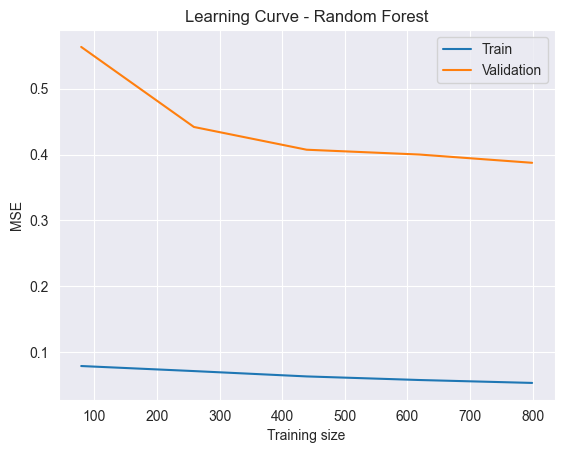

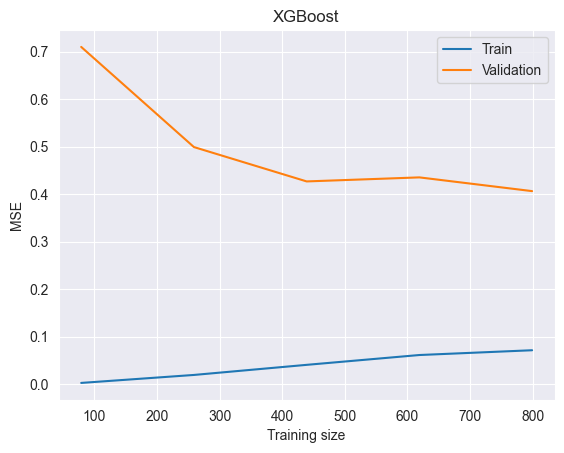

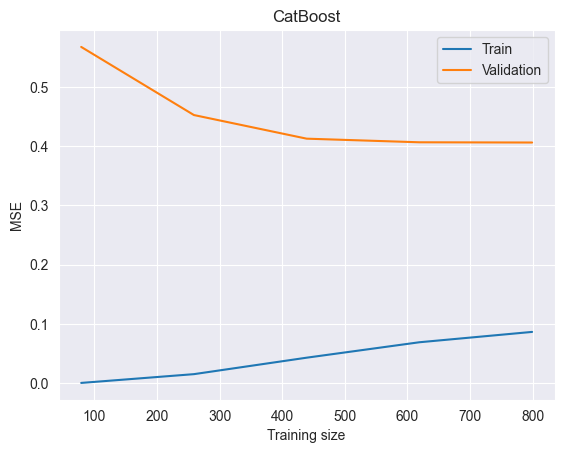

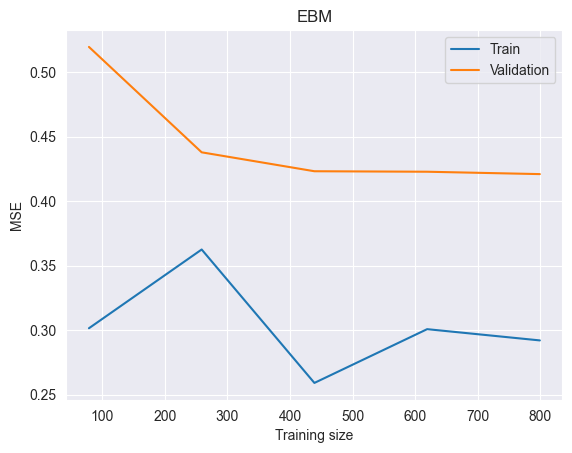

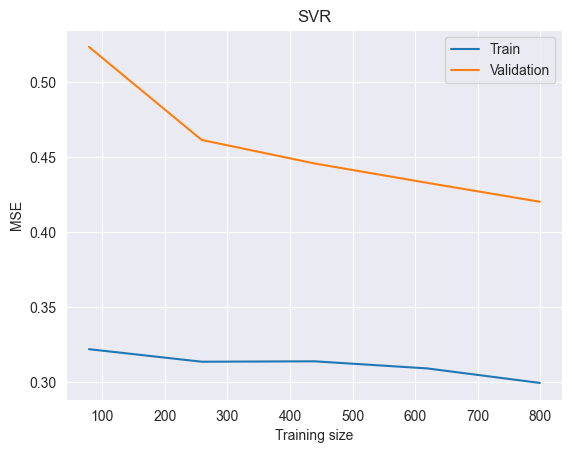

In [19]:
plot_learning_curve(rf_grid.best_estimator_, X_train, y_train, "Learning Curve - Random Forest")
plot_learning_curve(xgb_grid.best_estimator_, X_train, y_train, "XGBoost")
plot_learning_curve(cat_grid.best_estimator_, X_train, y_train, "CatBoost")
plot_learning_curve(ebm_grid.best_estimator_, X_train, y_train, "EBM")
plot_learning_curve(svr_grid.best_estimator_, X_train_scaled, y_train, "SVR")

## 4.5 Curbele de invatare - analiza

Din graficele obtinute se observa ca pentru majoritatea modelelor exista o diferenta clara intre eroarea pe setul de antrenare si cea pe setul de validare.

Pentru Random Forest si CatBoost, eroarea pe setul de antrenare este foarte mica, in timp ce eroarea pe setul de validare este semnificativ mai mare. Aceasta diferenta indica o tendinta de overfitting, deoarece modelele invata foarte bine datele de antrenare, dar generalizeaza mai slab pe date noi.

In cazul XGBoost, diferenta dintre cele doua curbe este mai mica, iar curbele tind sa se apropie pe masura ce creste numarul de exemple de antrenare. Acest lucru sugereaza o capacitate mai buna de generalizare.

Pentru SVR, diferentele dintre curbe sunt relativ reduse, ceea ce indica faptul ca modelul nu sufera de overfitting semnificativ si generalizeaza mai bine, insa performanta sa este mai slaba comparativ cu modelele ensemble.

Modelul EBM prezinta o diferenta moderata intre cele doua curbe, sugerand un compromis intre complexitate si generalizare.

Nu se observa cazuri evidente de underfitting, deoarece niciun model nu are erori mari simultan pe setul de antrenare si pe cel de validare.

## 4.6 Explicabilitatea si analiza SHAP

Analiza a fost efectuata pentru primele 3 modele dupa performanta: Random Forest ,CatBoost si SVR si am urmarit diferenta dintre acestea prin rezultatele graficelor.

In [20]:
# SHAP
best_model = rf_grid.best_estimator_
best_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [21]:
explainer = shap.Explainer(best_model, X_train)

In [22]:
shap_values = explainer(X_test)

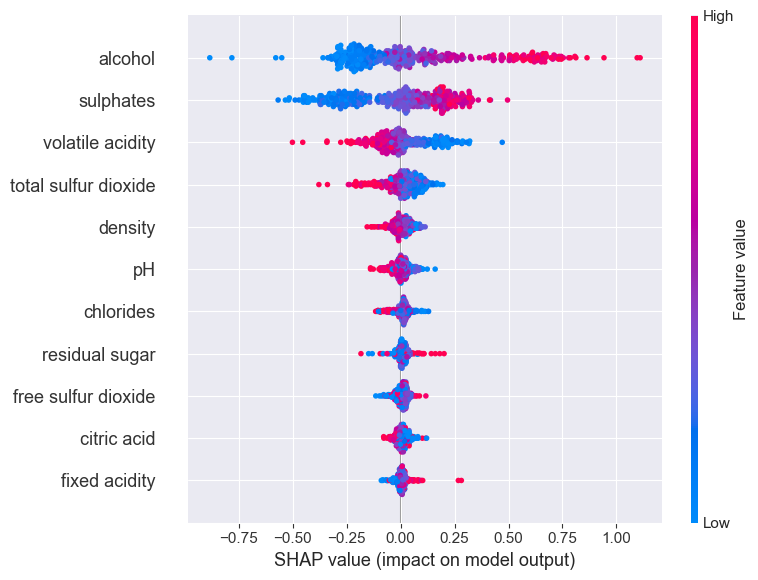

In [23]:
shap.summary_plot(shap_values, X_test)

### Importanta globala a caracteristicilor

Graficul SHAP summary evidentiaza impactul global al fiecarei caracteristici asupra predictiilor. Se observa ca variabila *alcohol* are cea mai mare influenta, urmata de *sulphates* si *volatile acidity*.

Valorile mari ale variabilei *alcohol* conduc la cresterea scorului de calitate, in timp ce valorile mari ale *volatile acidity* au un impact negativ asupra predictiei. Aceasta indica faptul ca modelele au invatat corect relatiile dintre caracteristici si calitatea vinului.

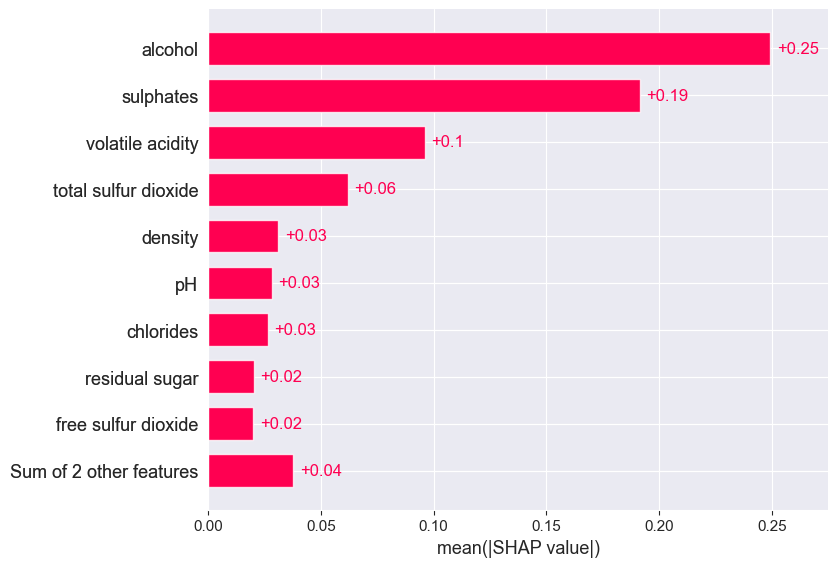

In [24]:
shap.plots.bar(shap_values)

### Importanta medie a caracteristicilor

Graficul de tip bar confirma rezultatele din summary plot, aratand ca cele mai importante caracteristici sunt *alcohol*, *sulphates* si *volatile acidity*. Aceste variabile contribuie cel mai mult la deciziile modelului.


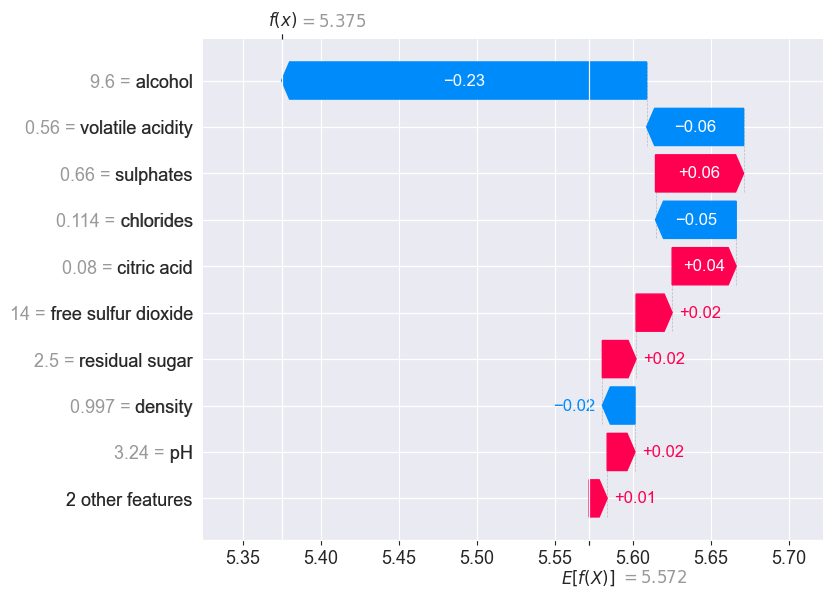

In [25]:
shap.plots.waterfall(shap_values[0])

### Explicatie locala a predictiei

Graficul waterfall arata contributia fiecarei caracteristici la predictia finala. Valoarea de baza este aproximativ 5.57, iar predictia finala este mai mica (~5.3).

Variabila *alcohol* are cel mai mare impact negativ, urmata de *volatile acidity* si *chlorides*, care reduc scorul. In schimb, *sulphates* si *citric acid* contribuie pozitiv, dar cu un efect mai mic.

In concluzie, predictia este influentata in principal de factorii negativi, care depasesc contributiile pozitive.

In [26]:
shap.initjs()
shap.plots.force(shap_values[0])

### Reprezentarea contributiilor caracteristicilor

Graficul force arata modul in care caracteristicile influenteaza predictia, impingand rezultatul in sus sau in jos fata de valoarea medie.

Variabilele marcate cu rosu cresc predictia, iar cele cu albastru o scad.

Caracteristicile care contribuie pozitiv sunt reprezentate intr-o directie, iar cele cu impact negativ in directia opusa, oferind o imagine clara asupra echilibrului dintre influentele variabilelor.

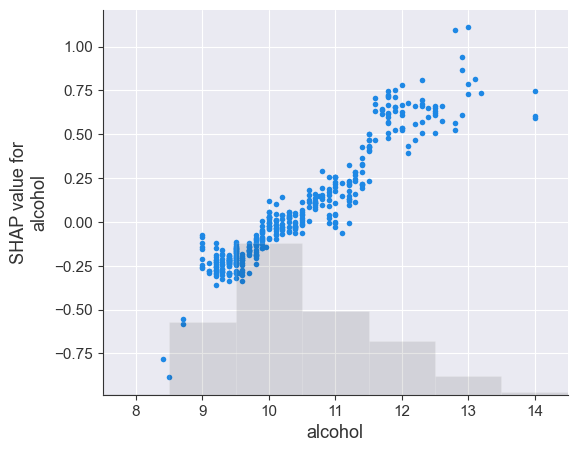

In [27]:
shap.plots.scatter(shap_values[:, "alcohol"])

### Influenta variabilei alcohol

Graficul arata o relatie puternic pozitiva intre alcohol si predictie. Valorile mici ale alcoolului au un impact negativ, in timp ce valorile mari conduc la valori SHAP pozitive, crescand scorul de calitate.

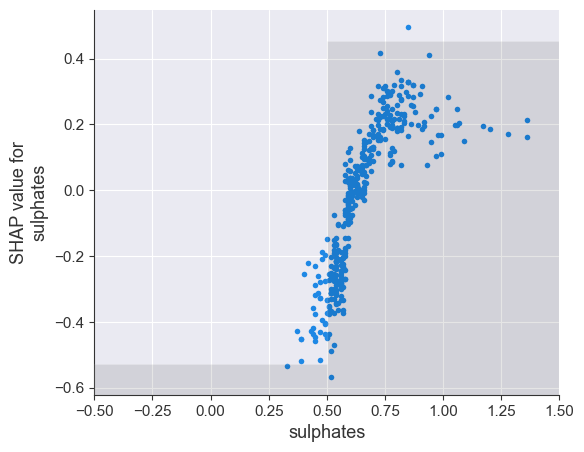

In [28]:
shap.plots.scatter(shap_values[:, "sulphates"])

### Influenta variabilei sulphates

Valorile mici ale variabilei sulphates au un impact negativ asupra predictiei, in timp ce valorile mari contribuie pozitiv. Se observa o relatie clara crescatoare, ceea ce indica faptul ca o crestere a acestei caracteristici duce la cresterea scorului de calitate.
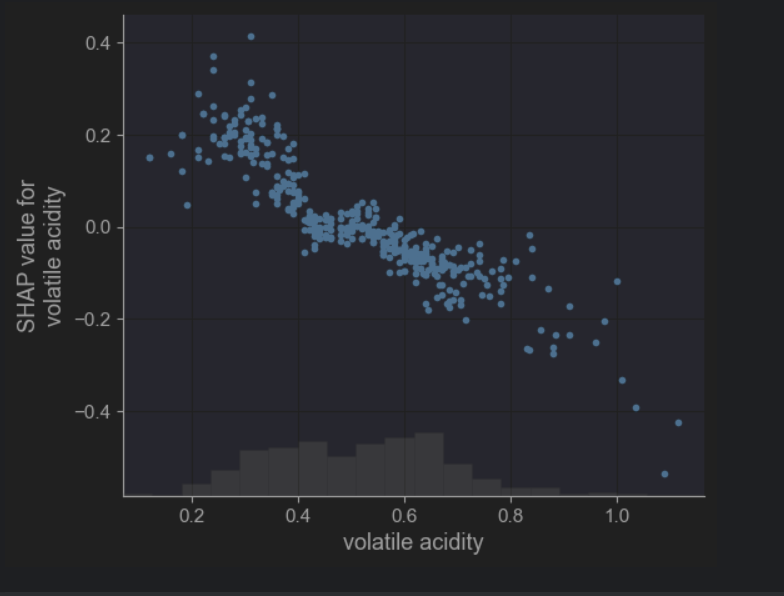

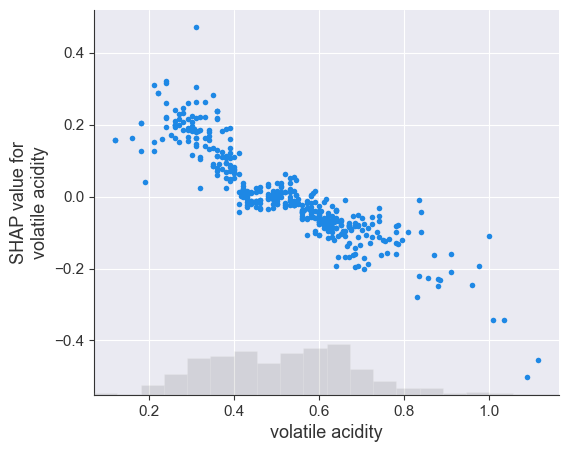

In [29]:
shap.plots.scatter(shap_values[:, "volatile acidity"])

### Influenta variabilei volatile acidity

Se observa o relatie negativa intre volatile acidity si predictie. Valorile mici contribuie pozitiv la scor, in timp ce valorile mari au un impact negativ, reducand calitatea vinului.

In [30]:
# explainer
explainer_cat = shap.Explainer(cat_grid.best_estimator_, X_train)

# shap values
shap_values_cat = explainer_cat(X_test)

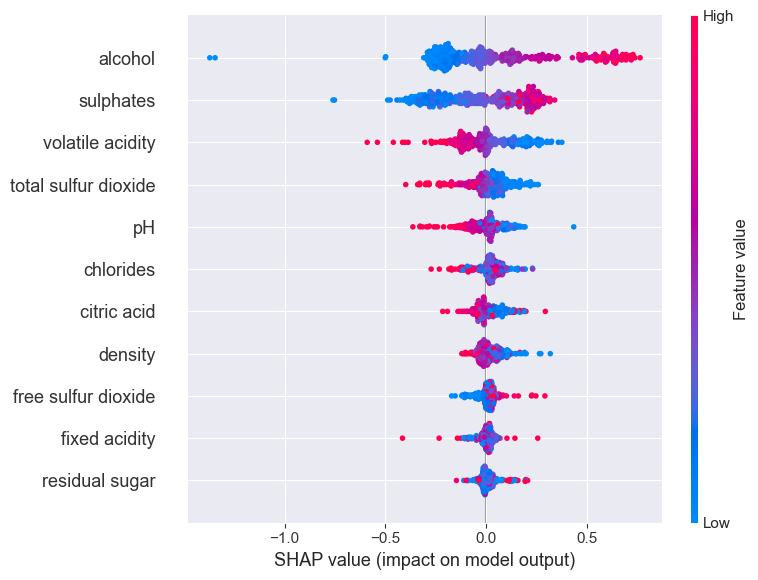

In [31]:
shap.summary_plot(shap_values_cat, X_test)



Se observa ca *alcohol* este cea mai importanta variabila, urmata de *sulphates* si *volatile acidity*.
Valorile mari ale alcohol si sulphates cresc scorul de calitate (SHAP pozitiv), in timp ce valori mari ale volatile acidity il reduc (SHAP negativ).

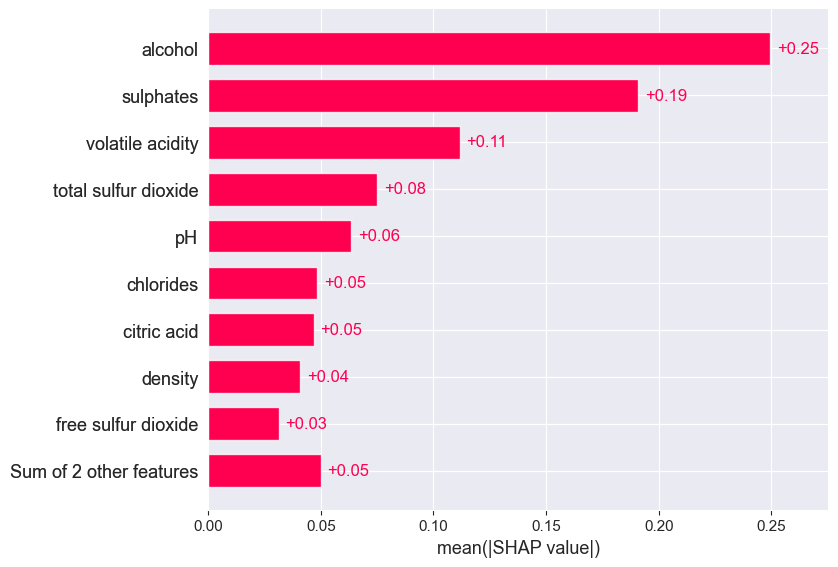

In [32]:
shap.plots.bar(shap_values_cat)


Cele mai influente variabile sunt *alcohol*, *sulphates* si *volatile acidity*, acestea avand cel mai mare impact asupra predictiilor modelului.
Restul caracteristicilor au contributii mai reduse.

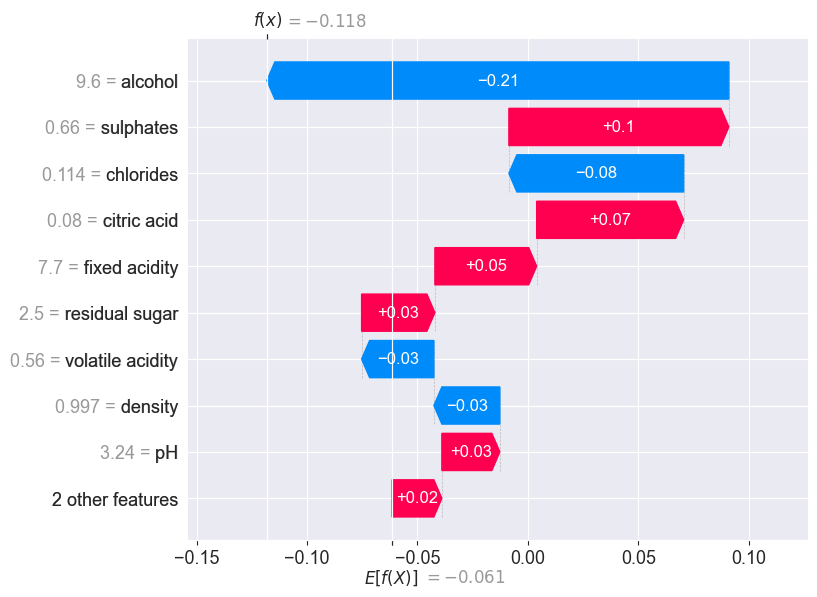

In [36]:
shap.plots.waterfall(shap_values_cat[0])


Se observa ca *alcohol* are un impact negativ puternic asupra predictiei, in timp ce *sulphates* si *citric acid* contribuie pozitiv.
Predictia finala este rezultatul combinatiei acestor influente pozitive si negative.

In [37]:
shap.plots.force(shap_values_cat[0])


Se observa ca mai multe caracteristici contribuie negativ, ceea ce explica valoarea finala mai mica a predictiei.

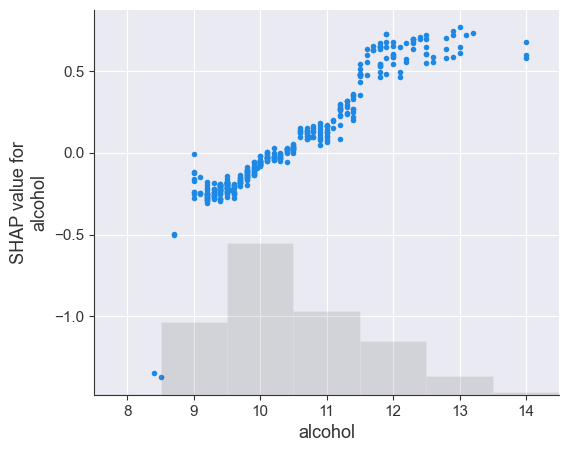

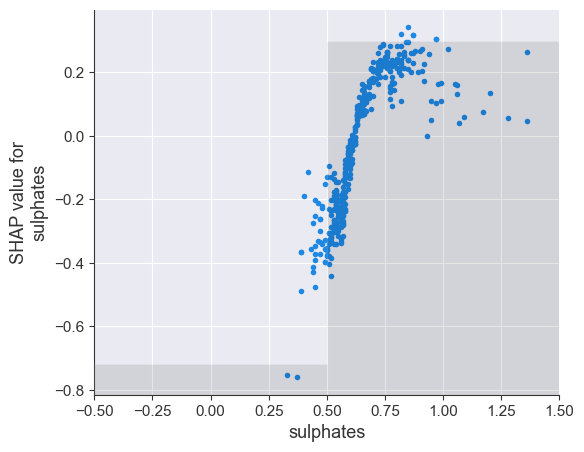

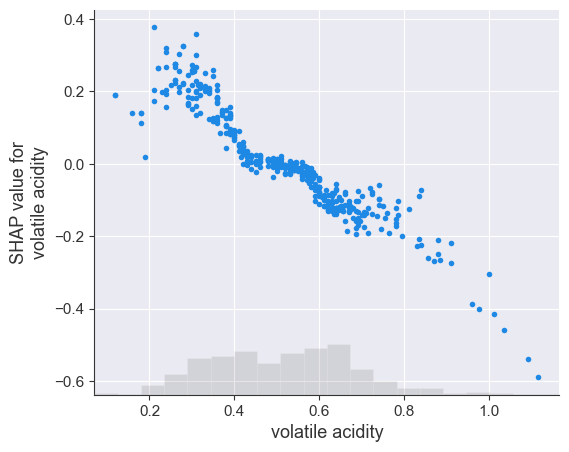

In [38]:
shap.plots.scatter(shap_values_cat[:, "alcohol"])
shap.plots.scatter(shap_values_cat[:, "sulphates"])
shap.plots.scatter(shap_values_cat[:, "volatile acidity"])

Se observa o relatie pozitiva intre *alcohol* si predictie.
Valorile mici ale alcoolului au impact negativ, iar valorile mari cresc scorul de calitate.
Relatia este clara si aproape liniara.

Variabila *sulphates* are un impact pozitiv asupra predictiei.
Pentru valori mici, contributia este negativa, iar dupa un anumit prag influenta devine pozitiva si creste rapid.
Acest lucru indica o relatie neliniara intre variabila si rezultat.

Se observa o relatie negativa intre *volatile acidity* si calitatea vinului.
Valorile mici au impact pozitiv, iar valorile mari reduc semnificativ predictia.
Aceasta este una dintre cele mai clare relatii inverse din model.

In [39]:
explainer_svr = shap.KernelExplainer(
    svr_grid.best_estimator_.predict,
    X_train_scaled[:100]   # subset pentru viteza
)

In [40]:
shap_values_svr = explainer_svr.shap_values(X_test_scaled[:50])

100%|██████████| 50/50 [08:23<00:00, 10.08s/it]


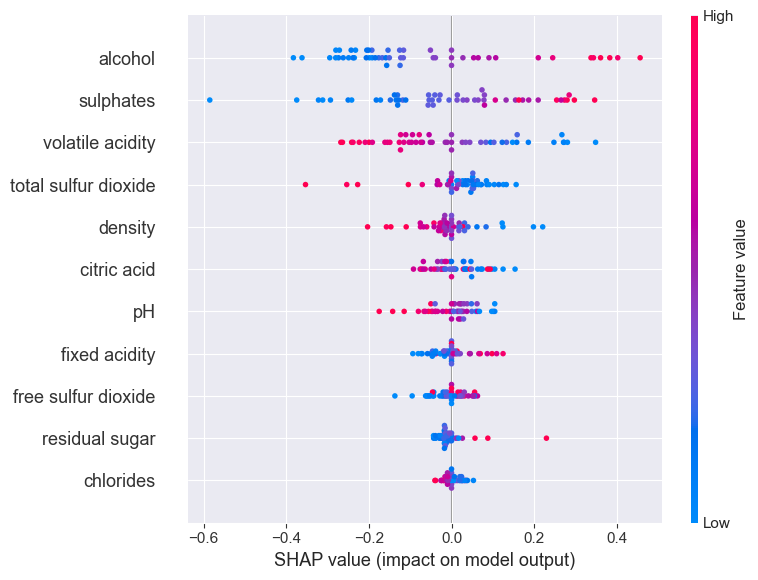

In [41]:
shap.summary_plot(shap_values_svr, X_test_scaled[:50], feature_names=X.columns)

Graficul summary arata importanta globala a caracteristicilor pentru modelul SVR.
Cele mai influente variabile sunt *alcohol*, *sulphates* si *volatile acidity*.
Valorile mari ale alcohol si sulphates cresc predictia, in timp ce valori mari ale volatile acidity o reduc.

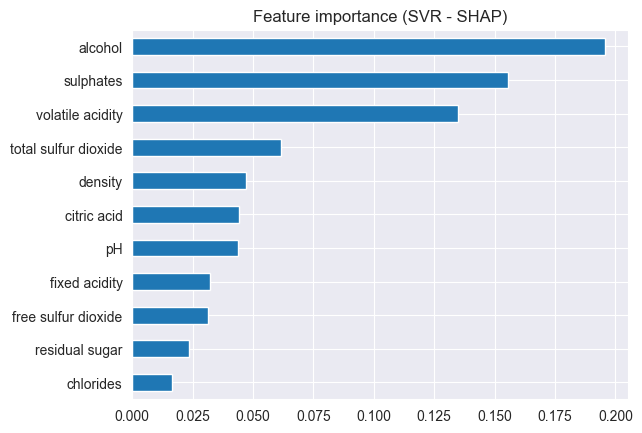

In [42]:
mean_abs_shap = np.abs(shap_values_svr).mean(axis=0)

feature_importance = pd.Series(mean_abs_shap, index=X.columns)
feature_importance.sort_values().plot(kind="barh")

plt.title("Feature importance (SVR - SHAP)")
plt.show()


*alcohol* are cel mai mare impact asupra modelului, urmat de *sulphates* si *volatile acidity*.
Restul variabilelor au contributii mai mici, dar nu neglijabile.

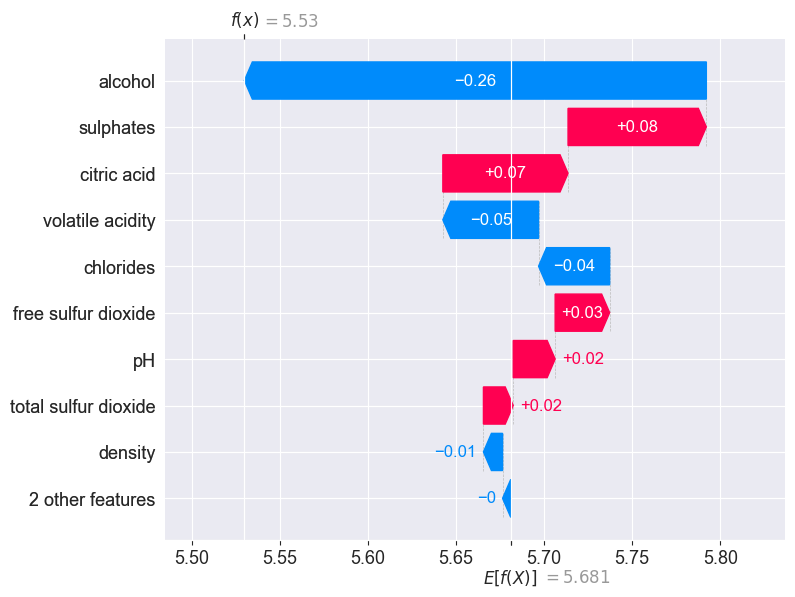

In [43]:
shap.plots._waterfall.waterfall_legacy(
    explainer_svr.expected_value,
    shap_values_svr[0],
    feature_names=X.columns
)


*alcohol* are cel mai mare impact negativ in timp ce *sulphates* si *citric acid* contribuie pozitiv.
Predictia finala este rezultatul combinarii acestor influente.

In [44]:
shap.initjs()

shap.force_plot(
    explainer_svr.expected_value,
    shap_values_svr[0],
    feature_names=X.columns
)


Se observa ca *alcohol*, *volatile acidity* si *chlorides* contribuie negativ in acest exemplu.

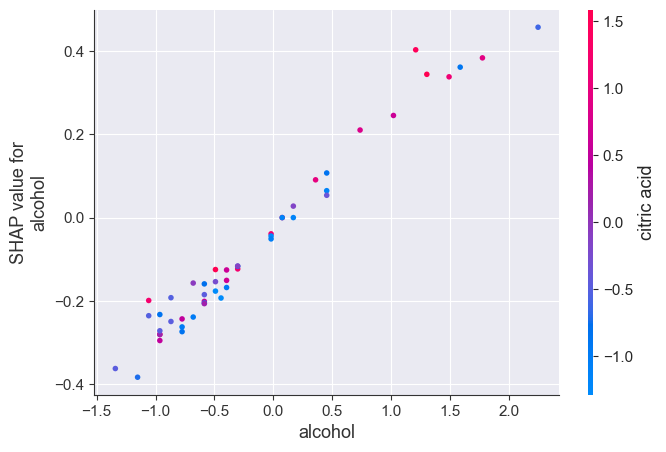

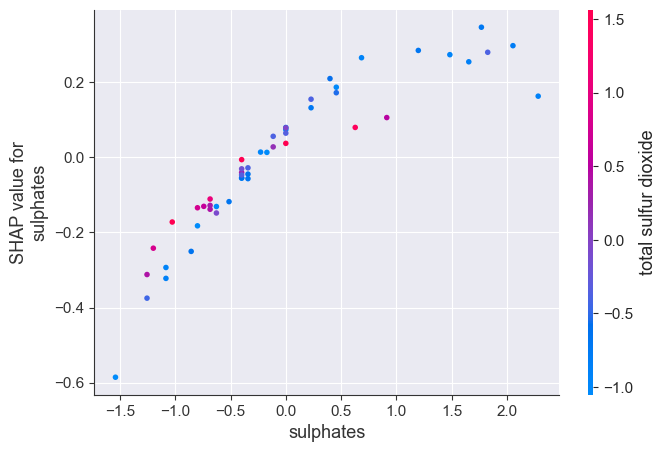

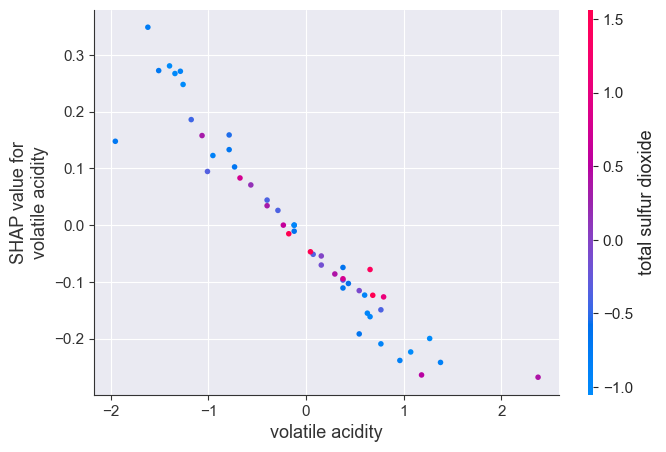

In [45]:
shap.dependence_plot("alcohol", shap_values_svr, X_test_scaled[:50], feature_names=X.columns)
shap.dependence_plot("sulphates", shap_values_svr, X_test_scaled[:50], feature_names=X.columns)
shap.dependence_plot("volatile acidity", shap_values_svr, X_test_scaled[:50], feature_names=X.columns)

Se observa o relatie pozitiva intre *alcohol* si predictie.
Valorile mici ale alcoolului au impact negativ, iar valorile mari cresc scorul de calitate.
Relatia este aproape liniara si clara.

Variabila *sulphates* are un impact pozitiv asupra predictiei.
Pe masura ce valorile cresc, SHAP devine pozitiv, indicand cresterea calitatii.
Relatia este clara si consistenta.

Se observa o relatie negativa intre *volatile acidity* si predictie.
Valorile mici contribuie pozitiv, iar valorile mari reduc semnificativ scorul.
Aceasta este una dintre cele mai puternice relatii inverse din model.

## Concluzie privind comportamentul modelelor perfectionate

Analiza SHAP confirma faptul ca toate modelele au identificat aceleasi caracteristici relevante, in special *alcohol*, *sulphates* si *volatile acidity*, ceea ce arata consistenta intre modele si corectitudinea invatarii.

In concluzie, modelele perfectionate reusesc sa ofere predictii precise si interpretari coerente, iar utilizarea tehnicilor de explicabilitate contribuie semnificativ la intelegerea modului in care caracteristicile influenteaza rezultatul final.